In [1]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

import lazypredict 
from lazypredict import Supervised 
from lazypredict.Supervised import LazyClassifier
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
plt.style.use('fivethirtyeight')
plt.rcParams["figure.figsize"] = (10,5)
import pandas as pd
import numpy as np

# Load libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn import datasets
# Import train_test_split function
from sklearn.model_selection import train_test_split
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

from sklearn.metrics import classification_report

import imblearn #should be install globally
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Apply SVM Model
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import auc,roc_auc_score,roc_curve

In [2]:
random_state = 42

In [3]:
data_path = "data/cardinality.csv"
data = pd.read_csv(data_path)
data.shape

(41, 17390)

In [4]:
data.head(5)

,Outcomes,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,OR6Q1,OR2AG1,PPIAL4F,PRAMEF18,OR8B4,PCDH20,PAGR1,RPS4Y2,ADORA3,EXOC3L2
0,0,92.87,1.02,255.15,373.54,110.22,20.41,5125.43,340.88,620.52,...,1.02,1.02,2.04,1.02,1.02,2.04,4.08,1.02,1.02,801.17
1,0,309.36,1.04,1.04,887.46,289.57,29.17,484.35,399.98,1415.56,...,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1350.98
2,0,101.04,1.02,204.12,368.44,113.29,20.41,4331.41,353.13,650.12,...,1.02,1.02,2.04,1.02,1.02,2.04,4.08,1.02,1.02,769.53
3,0,89.81,2.04,191.87,394.97,117.37,21.43,4269.15,342.92,647.06,...,1.02,1.02,2.04,1.02,1.02,2.04,3.06,1.02,1.02,889.96
4,0,52.05,1.02,468.45,122.47,139.82,20.41,3437.37,359.25,800.15,...,1.02,1.02,1.02,1.02,1.02,1.02,0.00,1.02,1.02,1342.08


In [5]:
#data splitting Pipeline,  labels and features

cols_labels = data.columns.tolist()
cols_labels.pop(0)

data_features = pd.read_csv(data_path, usecols = cols_labels)

data_labels = pd.read_csv(data_path, usecols = ['Outcomes'])

In [6]:
X_new = data_features

In [7]:
#print("X_new.shape: ", X_new.shape)
#print("X shape: ", X.shape)

In [8]:
#X = np.asarray(data_features)
#y = np.asarray(data_labels)
X = data_features
X = StandardScaler().fit_transform(X)
y = data_labels
#X = preprocessing.scale(X)

#X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
print("X_train.shape: ", X_train.shape)
print("y_train.shape: ", y_train.shape)
print("X_test.shape: ", X_test.shape)
print("y_test.shape: ", y_test.shape)

X_train.shape:  (32, 17389)
y_train.shape:  (32, 1)
X_test.shape:  (9, 17389)
y_test.shape:  (9, 1)


In [10]:
count_1 = y_test['Outcomes'].eq(1).sum()
count_0 = y_test['Outcomes'].eq(0).sum()
print("count_1: ", count_1)
print("count_0: ", count_0)

count_1:  6
count_0:  3


In [11]:
#............................................................random forestsime
model = RandomForestClassifier(random_state=42, criterion= 'gini', max_depth=5, n_estimators=10)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42)

In [12]:
#................................................................................................test data
y_pred=model.predict(X_test)

print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

test_fpr, test_tpr, thresholds = roc_curve(y_test, y_pred)

print('Area under test auc {}'.format(auc(test_fpr, test_tpr)))
print(classification_report(y_test, y_pred))


Accuracy: 0.7777777777777778
Area under test auc 0.7500000000000002
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.83      0.83      0.83         6

    accuracy                           0.78         9
   macro avg       0.75      0.75      0.75         9
weighted avg       0.78      0.78      0.78         9



In [13]:

#model = DecisionTreeClassifier(max_depth=5,min_samples_split=100)
#model = SVC(kernel='linear', C=1, gamma=1) 
model = RandomForestClassifier(random_state=42, criterion= 'gini', max_depth=5, n_estimators=10)
'''
model = ExtraTreesClassifier(n_estimators = ,
                                 max_depth = ,
                                 min_samples_split =,
                                 min_samples_leaf = ,
                                 criterion = ,
                                 random_state = random_state,
                                 n_jobs = -1)
'''
#rfe without cross validation
from sklearn.feature_selection import RFE
# n_features_to_select = 20
# rfe = RFE(model, n_features_to_select=n_features_to_select)
# rfe.fit(X_train, y_train)

#rfe with cross validation
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(2), scoring='roc_auc', min_features_to_select = 20) #min_features_to_select = , #n_features_to_select = 
rfecv.fit(X_train,y_train)

print('Optimal number of features: {}'.format(rfecv.n_features_))




Optimal number of features: 50


In [18]:
#indices = np.where(rfe.support_ == True)[0]
indices = rfecv.get_support(indices=True)

In [19]:
selected_features_indices = indices.tolist()

In [20]:
# Get the column names of the selected features
selected_features = X_new.iloc[:,selected_features_indices]

In [21]:
selected_features.shape

(41, 50)

In [22]:
#print(np.where(rfecv.support_ == True)[0])
#top_feats = X_train.columns[np.where(rfecv.support_ == True)[0]]
#top_feats = [  5, 18,  69 , 74 , 80 , 91  ,99 ,128, 151 ,216 ,233 ,245 ,255, 261 ,280, 283]
#top_feats

In [23]:
top_features = list(selected_features.columns)
top_features.append('Outcomes')
top_features

['TBC1D3F',
 'DUSP14',
 'SPATA31A7',
 'UHRF1',
 'OR13C2',
 'HIST1H4I',
 'PIK3R6',
 'TADA2A',
 'PIP4K2B',
 'HIST1H2AJ',
 'HIST1H2BF',
 'PCGF2',
 'SRCIN1',
 'GPR179',
 'MARCKS',
 'ZNF670',
 'GPIHBP1',
 'OR13C5',
 'NEFL',
 'HIST1H3F',
 'PSMB3',
 'SRD5A2',
 'CISD3',
 'DDX52',
 'TEX28',
 'ZNF8',
 'SSTR3',
 'MYO19',
 'HIST1H3C',
 'TBC1D3C',
 'GGNBP2',
 'ZNF229',
 'HIST1H2AB',
 'C17orf78',
 'DHRS11',
 'ACACA',
 'TMEM191B',
 'NR2E3',
 'HIST1H2BI',
 'MRM1',
 'HIST1H4A',
 'GOLGA6L10',
 'HIST1H2AM',
 'HIST1H4B',
 'HIST1H3H',
 'MRPL45',
 'OR2S2',
 'OR6Q1',
 'OR2AG1',
 'PPIAL4F',
 'Outcomes']

In [24]:
len(selected_features_indices)

50

In [25]:
selected_features['Outcomes'] = data['Outcomes']

In [26]:
selected_features.to_csv("data/rfe50-CV.csv", index=False)

(28, 31)

In [23]:
from sklearn.metrics import auc,roc_auc_score,roc_curve
best_est =  RandomForestClassifier(random_state=42, criterion= 'gini', max_depth=4, n_estimators=50)
best_est = best_est.fit(X_train[:, selected_features_indices],y_train)
train_fpr, train_tpr, thresholds = roc_curve(y_train, best_est.predict_proba(X_train[:,selected_features_indices])[:,1])
test_fpr, test_tpr, thresholds = roc_curve(y_test, best_est.predict_proba(X_test[:, selected_features_indices])[:,1])


print(f'Results with reduced features')
print('Area under train roc {}'.format(auc(train_fpr, train_tpr)))
print('Area under test roc {}'.format(auc(test_fpr, test_tpr)))

Results with reduced features
Area under train roc 1.0
Area under test roc 1.0


In [24]:
#######################...........................................................applying SMOTE

In [27]:
sm = SMOTE(sampling_strategy='minority', random_state=4)
X_train, y_train = sm.fit_resample(X_train[:, selected_features_indices], y_train)

ValueError: Expected n_neighbors <= n_samples,  but n_samples = 4, n_neighbors = 6

In [25]:
# Create adaboost classifer object
model = RandomForestClassifier(random_state=42, criterion= 'gini', max_depth=4, n_estimators=10)
# Train Adaboost Classifer
model = model.fit(X_train, y_train)



In [26]:
#Predict the response for test dataset
y_pred = model.predict(X_test[:, selected_features_indices])
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
#91, 83, 94
#88, 80, 92

ValueError: X has 300 features, but RandomForestClassifier is expecting 9722 features as input.

Text(341.5833333333334, 0.5, 'predicted labels')

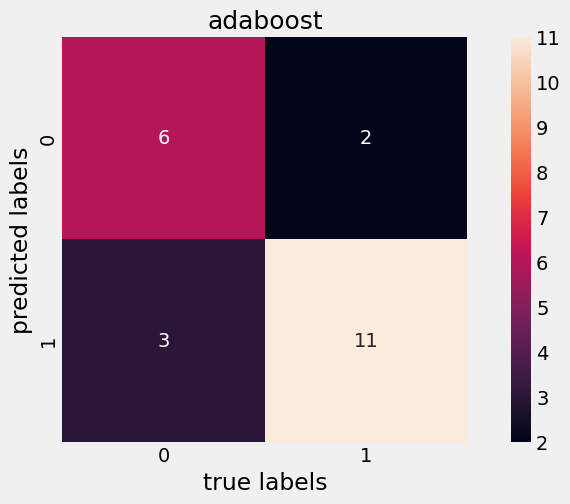

In [48]:
#Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

mat = confusion_matrix(y_test, y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=True,
           xticklabels = '01', yticklabels = '01')

plt.title('adaboost', fontsize=18, color='black')
plt.xlabel('true labels')
plt.ylabel('predicted labels')

In [ ]:
########################################################3333